# Stellar Magnitude Explorer - Histograms & Colour-Magnitude Diagram


## Objective
- Visualize the distribution of G-band apparent and absolute magnitudes, BP-RP colour indices and parallax.
- Construct a Colour-Magnitude Diagram (CMD) and Hertzsprung-Russell Diagram to identify stellar populations.

## Why this matters
- __Magnitude histograms__ shows sample completeness.
- __Colour index histogram__ reveals the dominant stellar types (e.g., peak near `bp_rp` ~ 0.8 for solar-type stars).
- __Parallax histogram__ shows us where our sources are mostly concentrated and their proximity.
- __CMD and HR Diagrams__ are a fundamental tool in astrophysics which is used to seperate stars by evolutionary stage.

## Dataset
- Input: `sources_with_galactic_coord_random.fits` (random sample, 10000 sources)
- Columns: `phot_g_mean_mag` (G-band magnitude), `bp_rp` (colour index), `parallax`
- Added Column: `abs_mag` (absolute magnitude) calculated from `phot_g_mean_mag` and `parallax` using Pogson's relation

## Goals for Today
- Load the random sample
- Plot histogram of `phot_g_mean_mag` and `abs_mag`(with bins and labels)
- Plot histogram of `bp_rp` (remove masked values)
- Plot histogram of `parallax`
- Calculate the absolute magnitude for each source using Pogson's relation
- Create Colour-Magnitude Diagrams and Hertzsprung-Russell Diagrams: `bp_rp` (x) vs `phot_g_mean_mag` (y) and `bp_rp` (x) vs `abs_mag` (y)
- Write interpretation: what do these diagrams tell me about the sources

## Checkpoint
- Magnitude histograms plotted
- Colour index histogram plotted (excluding missing values)
- Parallax histogram plotted
- Colour-Magnitude and Hertzsprung-Russell diagrams plotted with y-axis inverted (brighter stars at top)
- Brief interpretation of each figure

## Code 
### 1. Setup and Loading

In [1]:
from astropy.visualization import hist
from astropy.table import Table
import matplotlib.pyplot as plt
import textwrap
import numpy as np

In [2]:
table = Table.read("../../data/sources_with_galactic_coord_random.fits")
table.info()

<Table length=10000>
      name       dtype  unit    class     n_bad
--------------- ------- ---- ------------ -----
      source_id   int64            Column     0
             ra float64  deg       Column     0
            dec float64  deg       Column     0
          gal_l float64  deg       Column     0
          gal_b float64  deg       Column     0
       parallax float64  mas       Column     0
phot_g_mean_mag float32  mag       Column     0
          bp_rp float32  mag MaskedColumn    12


We will be using the `bp_rp` column for plotting our colour-index histogram and CMDs but it appears that there is missing data (represented by the `MaskedColumn` class object). We will approach this by filling missing values with `NaN` and drop them.

In [3]:
bp_rp_filled = table['bp_rp'].filled(np.nan)
bp_rp_clean = bp_rp_filled[~np.isnan(bp_rp_filled)]

Now we can use `bp_rp_clean` for our histogram and CMD plots instead of the `bp_rp` column.

We obtain the absolute (G-band) magnitude, $M_{G}$, by applying the Pogson's relation with distance modulus:

$M_{G} = m_{G} - 5log_{10}(d) + 5$                                     

where we substitute $d$ with $\frac{1000}{\varpi}$ and $\varpi$ represents parallax (`parallax`) in milliarcseconds. Therefore, we have:

$M_{G} = m_{G} - 5log_{10}(\frac{1000}{\varpi}) + 5$

$M_{G} = m_{G} - 5(3 - log_{10}(\varpi)) + 5$

$M_{G} = m_{G} - 15 + 5log_{10}(\varpi) + 5$

$M_{G} = m_{G} + 5log_{10}(\varpi) - 10$

We will use the final relation to calculate the absolute magnitude for each source and add a column, `abs_mag`, to the table that takes corresponding $M_{G}$ values. However, we should keep in mind that Gaia data is likely to have uncertainties and that the calculated values do not account for __interstellar extinction__.

In [4]:
table['abs_mag'] = table['phot_g_mean_mag'] + (5 * np.log10(table['parallax'])) - 10

# Saving the table with the new column to a FITS file
table.write("../../data/sources_with_abs_mag_random.fits", overwrite=True)
table.info()

<Table length=10000>
      name       dtype  unit    class     n_bad
--------------- ------- ---- ------------ -----
      source_id   int64            Column     0
             ra float64  deg       Column     0
            dec float64  deg       Column     0
          gal_l float64  deg       Column     0
          gal_b float64  deg       Column     0
       parallax float64  mas       Column     0
phot_g_mean_mag float32  mag       Column     0
          bp_rp float32  mag MaskedColumn    12
        abs_mag float64  mag       Column     0


### 2. Histograms

Now we can plot our histograms to observe distribution of sources based on magnitude, colour-indices, and parallax to confirm if there is a skewed tendency. We will use both a fixed number of bins and the Bayesian Blocks (`hist(bins='blocks'`) fitness function for our histograms. Bayesian Blocks binning will help identify and improve the resolution of statistically dense regions in the distributions.

#### 2.1 G-band Magnitude (`phot_g_mean_mag`) Histogram

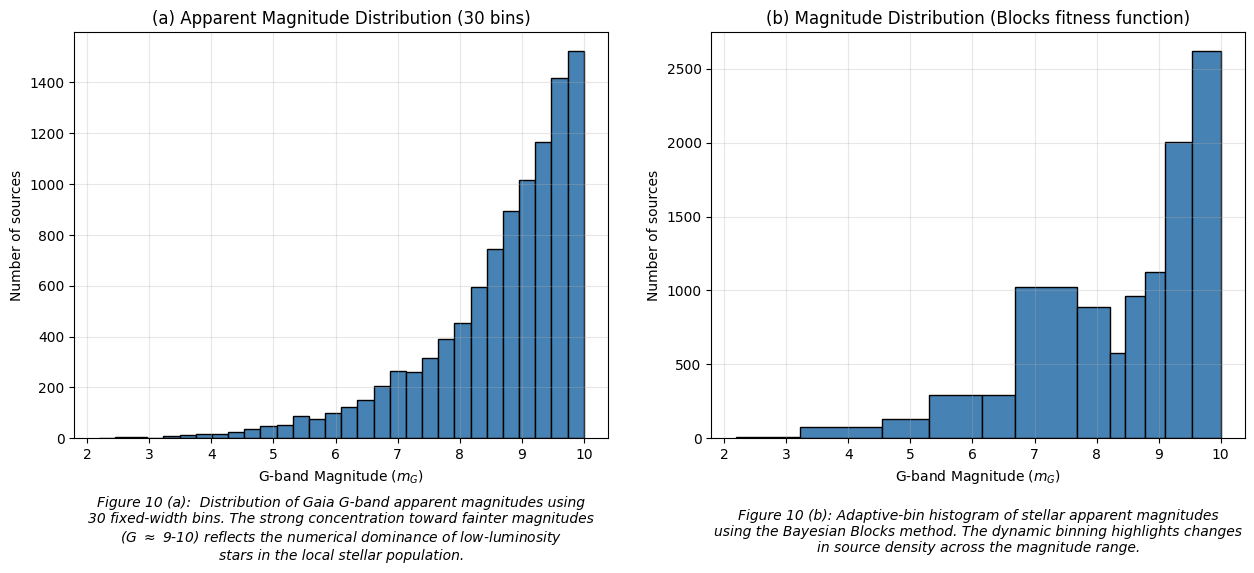

In [ ]:
# Plot Apparent Magnitude histogram

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))


# 30 bins
hist(table['phot_g_mean_mag'], bins=30, ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('(a) Apparent Magnitude Distribution (30 bins)')
ax1.set_xlabel(r'G-band Magnitude ($m_{G}$)')
ax1.set_ylabel('Number of sources')
ax1.grid(True, alpha=0.3)

# caption
fig_caption = r"""Figure 10 (a):  Distribution of Gaia G-band apparent magnitudes using 30 fixed-width bins. The strong concentration toward fainter
magnitudes (G $\approx$ 9-10) reflects the numerical dominance of low-luminosity stars in the local stellar population.
"""
wrapper = textwrap.TextWrapper(width=71)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax1.text(0.5, -0.3, fig_caption_wrapped, transform=ax1.transAxes, ha='center', fontsize=10, style='italic')


# Bayesian Blocks
hist(table['phot_g_mean_mag'], bins='blocks', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_title('(b) Magnitude Distribution (Blocks fitness function)')
ax2.set_xlabel(r'G-band Magnitude ($m_{G}$)')
ax2.set_ylabel('Number of sources')
ax2.grid(True, alpha=0.3)

# caption
fig_caption = """Figure 10 (b): Adaptive-bin histogram of stellar apparent magnitudes using the Bayesian Blocks method. The dynamic binning highlights changes
in source density across the magnitude range.
"""
wrapper = textwrap.TextWrapper(width=72)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax2.text(0.5, -0.28, fig_caption_wrapped, transform=ax2.transAxes, ha='center', fontsize=10, style='italic')


plt.tight_layout()
plt.savefig('../../outputs/mag_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.2 Absolute Magnitude Histogram

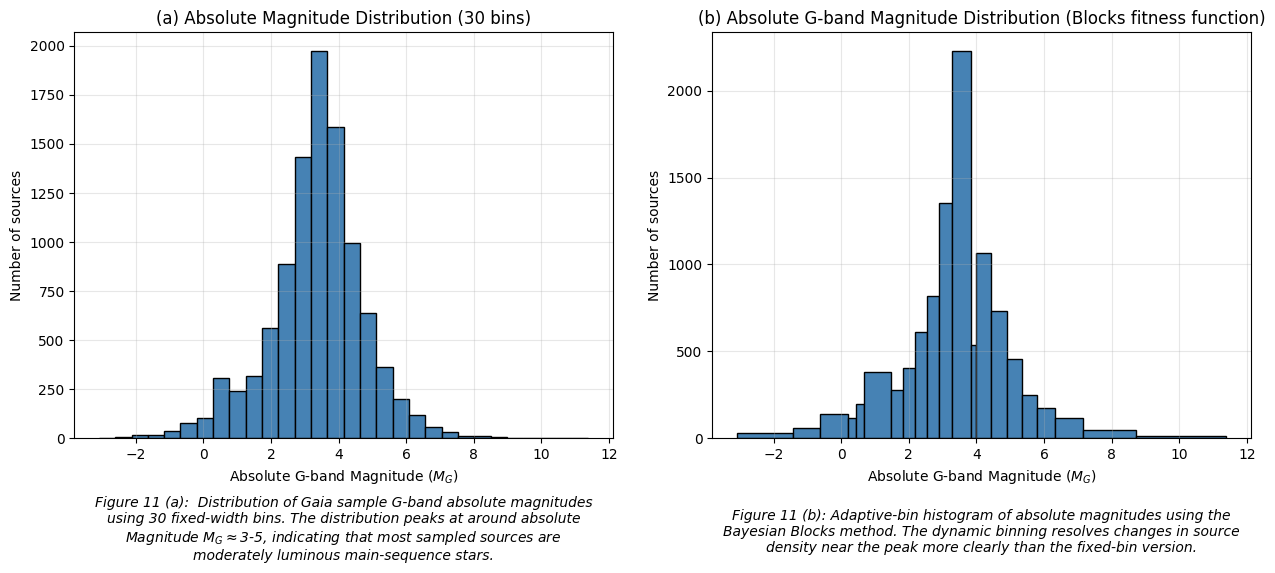

In [ ]:
# Plot Absolute Magnitude histogram

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))


# 30 bins
hist(table['abs_mag'], bins=30, ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('(a) Absolute Magnitude Distribution (30 bins)')
ax1.set_xlabel(r'Absolute G-band Magnitude ($M_{G}$)')
ax1.set_ylabel('Number of sources')
ax1.grid(True, alpha=0.3)

# caption
fig_caption = r"""Figure 11 (a):  Distribution of Gaia sample G-band absolute magnitudes using 30 fixed-width bins. The distribution peaks at around absolute
Magnitude $M_{G}\approx$3-5, indicating that most sampled sources are moderately luminous main-sequence stars.
"""
wrapper = textwrap.TextWrapper(width=71)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax1.text(0.5, -0.3, fig_caption_wrapped, transform=ax1.transAxes, ha='center', fontsize=10, style='italic')


# Bayesian Blocks 
hist(table['abs_mag'], bins='blocks', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_title('(b) Absolute G-band Magnitude Distribution (Blocks fitness function)')
ax2.set_xlabel(r'Absolute G-band Magnitude ($M_{G}$)')
ax2.set_ylabel('Number of sources')
ax2.grid(True, alpha=0.3)

# caption
fig_caption = """Figure 11 (b): Adaptive-bin histogram of absolute magnitudes using the Bayesian Blocks method. The dynamic binning resolves changes in
source density near the peak more clearly than the fixed-bin version.
"""
wrapper = textwrap.TextWrapper(width=72)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax2.text(0.5, -0.28, fig_caption_wrapped, transform=ax2.transAxes, ha='center', fontsize=10, style='italic')


plt.tight_layout()
plt.savefig('../../outputs/abs_mag_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### 2.3 Colour-Index (`bp_rp`) Histogram

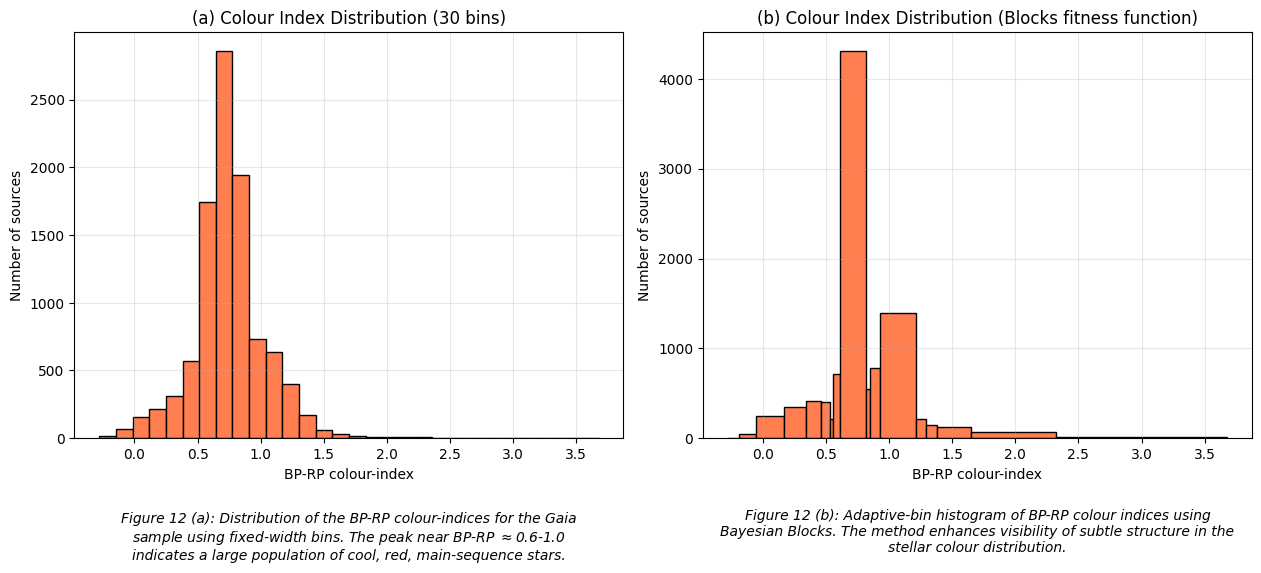

In [8]:
# Plot colour-index histograms

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))


# 30 bins
hist(bp_rp_clean, bins=30, ax=ax1, color='coral', edgecolor='black')
ax1.set_title('(a) Colour Index Distribution (30 bins)')
ax1.set_xlabel('BP-RP colour-index')
ax1.set_ylabel('Number of sources')
ax1.grid(True, alpha=0.3)

# caption
fig_caption = r"""Figure 12 (a): Distribution of the BP-RP colour-indices for the Gaia sample using fixed-width bins. The peak near BP-RP $\approx$0.6-1.0 indicates a large
population of cool, red, main-sequence stars.
"""
wrapper = textwrap.TextWrapper(width=74)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax1.text(0.5, -0.3, fig_caption_wrapped, transform=ax1.transAxes, ha='center', fontsize=10, style='italic')


# Bayesian Blocks
hist(bp_rp_clean, bins='blocks', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('(b) Colour Index Distribution (Blocks fitness function)')
ax2.set_xlabel('BP-RP colour-index')
ax2.set_ylabel('Number of sources')
ax2.grid(True, alpha=0.3)

# caption
fig_caption = """Figure 12 (b): Adaptive-bin histogram of BP-RP colour indices using Bayesian Blocks. The method enhances visibility of subtle structure in the stellar
colour distribution.
"""
wrapper = textwrap.TextWrapper(width=74)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax2.text(0.5, -0.28, fig_caption_wrapped, transform=ax2.transAxes, ha='center', fontsize=10, style='italic')


plt.tight_layout()
plt.savefig('../../outputs/bp-rp_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.4 Parallax (`parallax`) Histogram

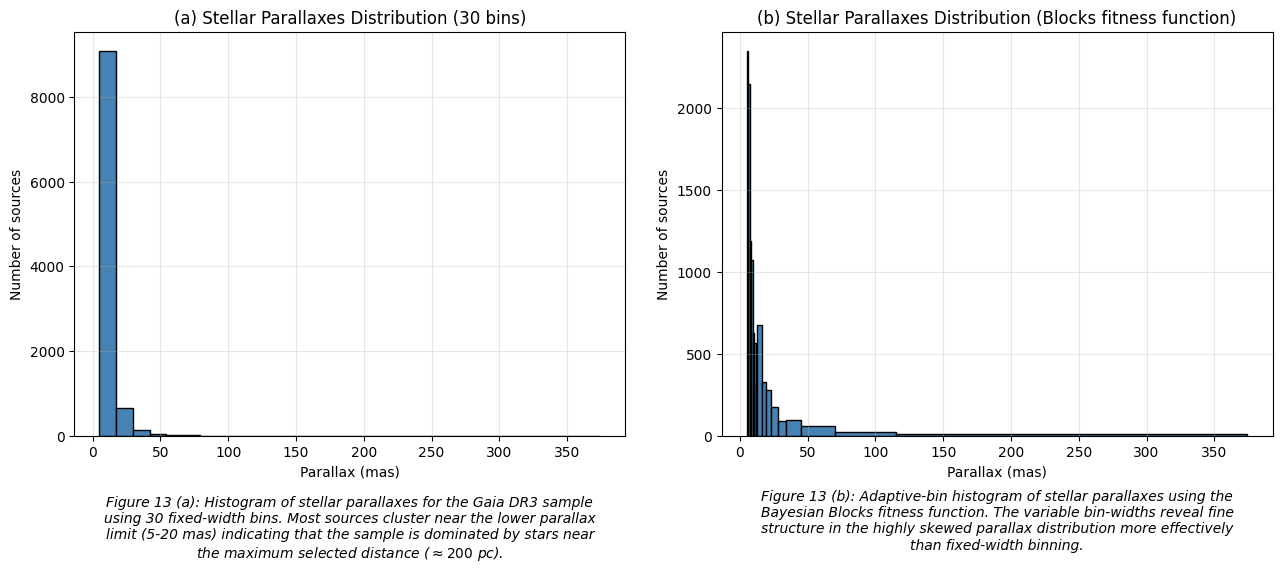

In [9]:
# Plot parallax histograms

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))


# 30 bins
hist(table['parallax'], bins=30, ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('(a) Stellar Parallaxes Distribution (30 bins)')
ax1.set_xlabel('Parallax (mas)')
ax1.set_ylabel('Number of sources')
ax1.grid(True, alpha=0.3)

# caption
fig_caption = r"""Figure 13 (a): Histogram of stellar parallaxes for the Gaia DR3 sample using 30 fixed-width bins. Most sources cluster near the lower parallax limit (5-20 mas)
indicating that the sample is dominated by stars near the maximum selected distance ($\approx 200\ pc$).
"""
wrapper = textwrap.TextWrapper(width=71)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax1.text(0.5, -0.3, fig_caption_wrapped, transform=ax1.transAxes, ha='center', fontsize=10, style='italic')



# Bayesian Blocks
hist(table['parallax'], bins='blocks', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_title('(b) Stellar Parallaxes Distribution (Blocks fitness function)')
ax2.set_xlabel('Parallax (mas)')
ax2.set_ylabel('Number of sources')
ax2.grid(True, alpha=0.3)

# caption
fig_caption = """Figure 13 (b): Adaptive-bin histogram of stellar parallaxes using the Bayesian Blocks fitness function. The variable bin-widths reveal fine structure in the
highly skewed parallax distribution more effectively than fixed-width binning.
"""
wrapper = textwrap.TextWrapper(width=72)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax2.text(0.5, -0.28, fig_caption_wrapped, transform=ax2.transAxes, ha='center', fontsize=10, style='italic')


plt.tight_layout()
plt.savefig('../../outputs/parallaxes_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 3. Colour-Magnitude Diagram and Hertzspring-Russell Diagram

In this section, we plot the sample's CMD using the apparent magnitude $m_{G}$ (`phot_g_mean_mag`) and the Hertzsprung-Russell diagram using the absolute magnitude $M_{G}$ (`abs_mag`). We use the scatter plot and hexbin plot to highlight difference in densities for each region.

#### 3.1. Colour-Magnitude Diagrams (Apparent-Magnitude)

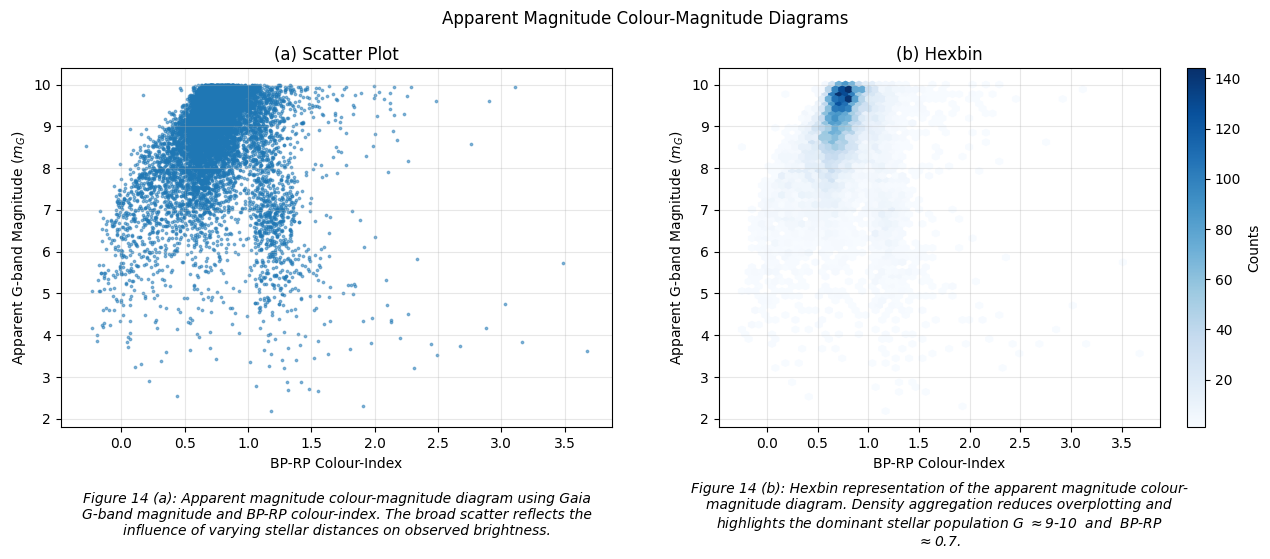

In [11]:
# Remove rows with missing bp_rp

mask = ~table['bp_rp'].mask
bp_rp_clean = table['bp_rp'][mask]
mag_clean = table['phot_g_mean_mag'][mask]


# Plot CMD histograms

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))


# Scatter plot
ax1.scatter(bp_rp_clean, mag_clean, s=3, alpha=0.5)
ax1.set_xlabel('BP-RP Colour-Index')
ax1.set_ylabel(r'Apparent G-band Magnitude ($m_{G}$)')
ax1.set_title('(a) Scatter Plot')
fig.gca().invert_yaxis()
ax1.grid(True, alpha=0.3)

# caption
fig_caption = r"""Figure 14 (a): Apparent magnitude colour-magnitude diagram using Gaia G-band magnitude and BP-RP colour-index. The broad scatter reflects the influence of varying
stellar distances on observed brightness.
"""
wrapper = textwrap.TextWrapper(width=71)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax1.text(0.5, -0.3, fig_caption_wrapped, transform=ax1.transAxes, ha='center', fontsize=10, style='italic')


# Hexbin plot
hb2 = ax2.hexbin(bp_rp_clean, mag_clean, gridsize=60, cmap='Blues', mincnt=1)
fig.colorbar(hb2, ax=ax2, label='Counts')
ax2.set_xlabel('BP-RP Colour-Index')
ax2.set_ylabel(r'Apparent G-band Magnitude ($m_{G}$)')
ax2.set_title('(b) Hexbin')
fig.gca().invert_yaxis()
ax2.grid(True, alpha=0.3)

# caption
fig_caption = r"""Figure 14 (b): Hexbin representation of the apparent magnitude colour-magnitude diagram. Density aggregation reduces overplotting and highlights the dominant
stellar population G $\approx$9-10  and  BP-RP $\approx$0.7.
"""
wrapper = textwrap.TextWrapper(width=72)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax2.text(0.5, -0.33, fig_caption_wrapped, transform=ax2.transAxes, ha='center', fontsize=10, style='italic')


plt.suptitle("Apparent Magnitude Colour-Magnitude Diagrams")
plt.tight_layout()
plt.savefig('../../outputs/colour-magnitude_diagrams.png', dpi=300, bbox_inches='tight')
plt.show()



#### 3.1. Hertzsprung-Russell Diagrams

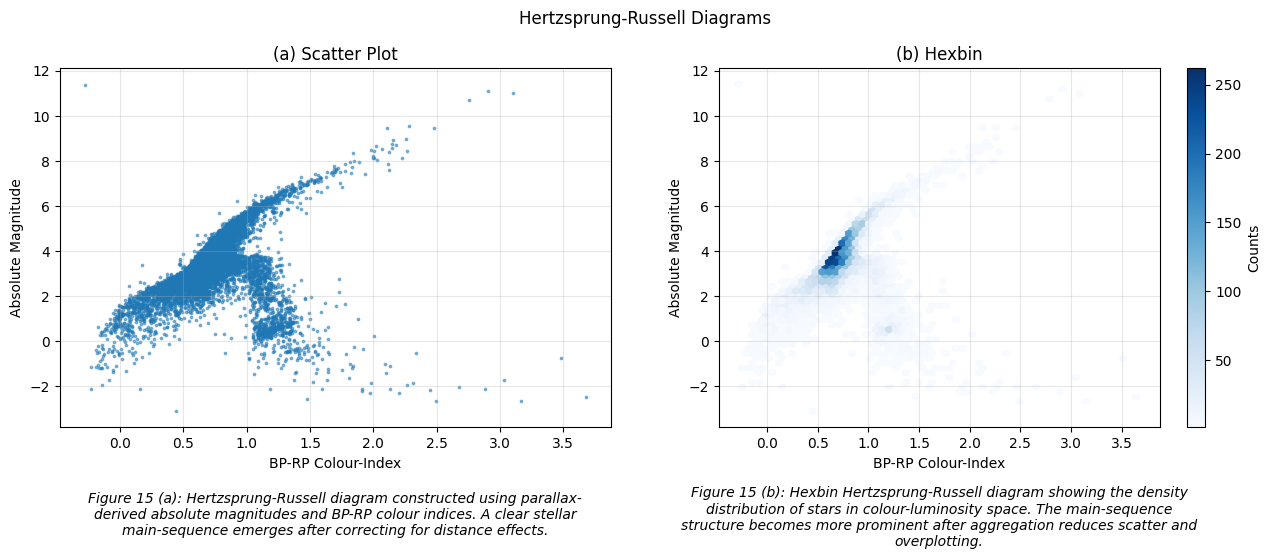

In [12]:
# Remove rows with missing bp_rp

abs_mag_clean = table['abs_mag'][mask]


# Plot HR diagrams

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))


# Scatter plot
ax1.scatter(bp_rp_clean, abs_mag_clean, s=3, alpha=0.5)
ax1.set_xlabel('BP-RP Colour-Index')
ax1.set_ylabel('Absolute Magnitude')
ax1.set_title('(a) Scatter Plot')
ax1.grid(True, alpha=0.3)

# caption
fig_caption = r"""Figure 15 (a): Hertzsprung-Russell diagram constructed using parallax-derived absolute magnitudes and BP-RP colour indices. A clear stellar
main-sequence emerges after correcting for distance effects.
"""
wrapper = textwrap.TextWrapper(width=71)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax1.text(0.5, -0.3, fig_caption_wrapped, transform=ax1.transAxes, ha='center', fontsize=10, style='italic')


# Hexbin plot
hb2 = ax2.hexbin(bp_rp_clean, abs_mag_clean, gridsize=60, cmap='Blues', mincnt=1)
fig.colorbar(hb2, ax=ax2, label='Counts')
ax2.set_xlabel('BP-RP Colour-Index')
ax2.set_ylabel('Absolute Magnitude')
ax2.set_title('(b) Hexbin')
ax2.grid(True, alpha=0.3)

# caption
fig_caption = r"""Figure 15 (b): Hexbin Hertzsprung-Russell diagram showing the density distribution of stars in colour-luminosity space. The main-sequence structure
becomes more prominent after aggregation reduces scatter and overplotting.
"""
wrapper = textwrap.TextWrapper(width=72)
lines = wrapper.wrap(text=fig_caption)
fig_caption_wrapped = '\n'.join(lines)
ax2.text(0.5, -0.33, fig_caption_wrapped, transform=ax2.transAxes, ha='center', fontsize=10, style='italic')


plt.suptitle("Hertzsprung-Russell Diagrams")
plt.tight_layout()
plt.savefig('../../outputs/hertzsprung-russel_diagrams.png', dpi=300, bbox_inches='tight')
plt.show()



## Observations

### Magnitude Distribution
#### Apparent G-band Magnitude Distribution

- The apparent magnitude distribution is concentrated toward fainter magnitudes ($G\approx 9-10$), showing that apparently faint stars dominate the nearby stellar population.

#### Absolute G-band Magnitude Distribution
- The absolute magnitude distribution is strongly concentrated between M $\approx 3-5$, suggesting that the sample is dominated by Sun-like and moderately faint main-sequence stars in the solar neighbourhood.
- Very luminous stars (with low or negative absolute magnitudes) are comparatively rare because such stars are intrinsically uncommon. 
- Very faint stars are also underrepresented because the dataset was filtered using an apparent magnitude limit ($G \lt 10$) which biases the sample toward brighter observable objects.
- The Bayesian Blocks histogram adapts its bin widths near the peak of the distribution, revealing finer structure where the local density of sources changes rapidly.

### Colour Index Distribution
- The BP-RP colour-index distribution peaks at around positive values ($\approx 0.6-10$) thus indicating that there are most stars in the sample are cool and red.- The distribution supports the interpretation that most stars are low-mass, mains-sequence dwarf stars.

### Parallax Distribution
- The parallax distribution is skewed strongly toward smaller parallaxes which indicates that most sources are found near the maximum distance closest to the sample selection threshold (`parallax > 5` mas).
- A small number of stars in the sample are found in the location nearest to our sun in our local volume.

### Apparent-Magnitude Colour-Magnitude Diagram
- The apparent-magnitude CMD shows a broad and diffuse stellar distribution with substantial scattering.
- The intrinsic relationship between stellar colour and luminosity cannot be inferred easily due to the effect of distance on the relative brightness of stars.

### Hertzsprung-Russel Diagram
- The stellar sequence becomes clearer after converting apparent magnitude to absolute magnitudes using parallax-derived distances.
- A well-defined main-sequence emerges, with hotter blue stars appearing intrinsically brighter and cooler red stars appearing intrinsically fainter.
- The reduction in scatter showcases how correcting for distance can aid in revealing the intrinsic properties of stars.


## Key Interpretation
The observed distributions highlight that late F-, G-, and early K-type cool, red dwarfs are present in the sample, which is indicative of the solar neighbourhood population.